#  <center> Speech Emotion Recognition <center>

Speech Emotion Recognition (SER) is based on recognising human emotion and affective states from speech. Our voices change a lot depending on how we feel—like when we're happy, we might speak faster and with a higher pitch, and when we're sad, our tone tends to drop and we speak more slowly. Things like pitch, tone, and even subtle patterns in how the sound waves look can tell a lot about what someone is feeling.

#### Why is important for my project?

It's important because giving the therapist chatbot more information about the user's emotions helps create a more meaningful conversation. Someone who is feeling sad or going through a tough time doesn’t want to talk to something that doesn’t acknowledge their emotional state.

#### Datasets used in this project

* Crowd-sourced Emotional Mutimodal Actors Dataset (Crema-D)
* Ryerson Audio-Visual Database of Emotional Speech and Song (Ravdess)
* Surrey Audio-Visual Expressed Emotion (Savee)
* Toronto emotional speech set (Tess)

# Importing Libraries

In [178]:
import pandas as pd
import numpy as np

import os
import sys

# librosa is a Python library for analyzing audio and music. It can be used to extract the data from the audio files we will see it later.
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# to record audio for testing
import sounddevice as sd
from scipy.io.wavfile import write

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

import kagglehub

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

## Data Preparation
* As we are working with four different datasets, so i will be creating a dataframe storing all emotions of the data in dataframe with their paths.
* We will use this dataframe to extract features for our model training.

## Datasets
* Ravdess: This portion of the RAVDESS contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

* Crema-D: a data set of 7,442 original clips from 91 actors. These clips were from 48 male and 43 female actors between the ages of 20 and 74 coming from a variety of races and ethnicities (African America, Asian, Caucasian, Hispanic, and Unspecified). Actors spoke from a selection of 12 sentences. The sentences were presented using one of six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).

* Tess: There are a set of 200 target words were spoken in the carrier phrase "Say the word _' by two actresses (aged 26 and 64 years) and recordings were made of the set portraying each of seven emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). There are 2800 data points (audio files) in total.
The dataset is organised such that each of the two female actor and their emotions are contain within its own folder. And within that, all 200 target words audio file can be found. The format of the audio file is a WAV format

* Savee: The SAVEE database was recorded from four native English male speakers (identified as DC, JE, JK, KL) aged from 27 to 31 years. Emotion has been described psychologically in discrete categories: anger, disgust, fear, happiness, sadness and surprise. This is supported by the cross-cultural studies of Ekman and studies of automatic emotion recognition tended to focus on recognizing these. We added neutral to provide recordings of 7 emotion categories. The text material consisted of 15 TIMIT sentences per emotion: 3 common, 2 emotion-specific and 10 generic sentences that were different for each emotion and phonetically-balanced. The 3 common and 2 × 6 = 12 emotion-specific sentences were recorded as neutral to give 30 neutral sentences.

In [286]:
# Paths for data.
Ravdess = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
Crema =  kagglehub.dataset_download("ejlok1/cremad")
Tess = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
Savee = kagglehub.dataset_download("barelydedicated/savee-database")

##  <center> 1. Ravdess Dataframe <center>
Here is the filename identifiers as per the official RAVDESS website:

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

So, here's an example of an audio filename. 02-01-06-01-02-01-12.mp4
This means the meta data for the audio file is:

* Video-only (02)
* Speech (01)
* Fearful (06)
* Normal intensity (01)
* Statement "dogs" (02)
* 1st Repetition (01)
* 12th Actor (12) - Female (as the actor ID number is even)

In [34]:
# 1. Prepare containers
file_emotions = []
file_paths    = []

# 2. Map code → label
emotion_map = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fear',
    7: 'disgust',
    8: 'surprise'
}

# 3. Walk through each actor subfolder
for actor_folder in os.listdir(Ravdess):
    actor_path = os.path.join(Ravdess, actor_folder)
    if not os.path.isdir(actor_path):
        continue

    for fname in os.listdir(actor_path):
        if not fname.lower().endswith('.wav'):
            continue

        parts = fname.split('.')[0].split('-')
        code  = int(parts[2])                         # the 3rd segment is emotion
        label = emotion_map.get(code, 'unknown')

        file_emotions.append(label)
        file_paths.append(  os.path.join(actor_path, fname) )

# 4. Build the DataFrame
Ravdess_df = pd.DataFrame({
    'Path':    file_paths,
    'Emotion': file_emotions
})

Ravdess_df.head()

,Path,Emotion
0,/Users/bernardoquindimil/.cache/kagglehub/data...,angry
1,/Users/bernardoquindimil/.cache/kagglehub/data...,fear
2,/Users/bernardoquindimil/.cache/kagglehub/data...,fear
3,/Users/bernardoquindimil/.cache/kagglehub/data...,angry
4,/Users/bernardoquindimil/.cache/kagglehub/data...,disgust


## <center>2. Crema DataFrame</center>

In [35]:
# 1. Prepare lists
file_paths = []
emotions   = []

# 2. Map codes → labels
emotion_map = {
    'SAD': 'sad',
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral'
}

# 3. Recursively find every .wav
for root, _, files in os.walk(Crema):
    for fname in files:
        if not fname.lower().endswith('.wav'):
            continue

        # Full path to file
        path = os.path.join(root, fname)
        file_paths.append(path)

        # CREMA-D filenames look like: "1001_32_P3_FEA.wav"
        parts = fname.split('_')
        code  = parts[2].upper()          # e.g. "FEA"
        label = emotion_map.get(code, 'unknown')
        emotions.append(label)

# 4. Build DataFrame
Crema_df = pd.DataFrame({
    'Path':    file_paths,
    'Emotion': emotions
})

print(f"Found {len(Crema_df)} files.")
print(Crema_df.head())

Found 7442 files.
                                                Path  Emotion
0  /Users/bernardoquindimil/.cache/kagglehub/data...    angry
1  /Users/bernardoquindimil/.cache/kagglehub/data...    angry
2  /Users/bernardoquindimil/.cache/kagglehub/data...  neutral
3  /Users/bernardoquindimil/.cache/kagglehub/data...  neutral
4  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust


##  <center> 3. TESS dataset <center>

In [36]:
# 1. Prepare containers
file_paths = []
emotions   = []

# 2. Map the 3-letter codes in TESS filenames to human-readable labels
emotion_map = {
    'ang': 'angry',
    'sad': 'sad',
    'dis': 'disgust',
    'fea': 'fear',
    'hap': 'happy',
    'neu': 'neutral',
    'ps':  'surprise'
}

# 3. Recurse into every subfolder and pick up .wav files
for root, _, files in os.walk(Tess):
    for fname in files:
        if not fname.lower().endswith('.wav'):
            continue

        # full path
        path = os.path.join(root, fname)
        file_paths.append(path)

        # filename looks like: “OAF_back_ang.wav” or “YAF_frustrated_ps.wav”
        parts = fname.split('.')[0].split('_')
        code  = parts[2].lower()               # the third segment
        label = emotion_map.get(code, code)    # fallback to code if unmapped
        emotions.append(label)

# 4. Build your DataFrame in one go
Tess_df = pd.DataFrame({
    'Path':    file_paths,
    'Emotion': emotions
})

print(Tess_df.head())

                                                Path  Emotion
0  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust
1  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust
2  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust
3  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust
4  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust


##  <center> 4. Savee dataset <center>

In [37]:
import os
import pandas as pd

# 0. Emotion map
emotion_map = {
    'a':  'angry',
    'd':  'disgust',
    'f':  'fear',
    'h':  'happy',
    'n':  'neutral',
    'sa': 'sad',
    'su': 'surprise'
}

# 1. Prepare containers
file_paths = []
emotions = []

# 2. Walk through every subfolder and collect .wav files
for root, _, files in os.walk(Savee):
    for fname in files:
        if not fname.lower().endswith('.wav'):
            continue
        
        full_path = os.path.join(root, fname)
        file_paths.append(full_path)

        # 3. Extract the emotion code (letter(s) before digits)
        base = os.path.splitext(fname)[0]  # Remove ".wav"
        code = ''.join(filter(str.isalpha, base))  # Keep only letters
        
        # 4. Map to full emotion label, fallback to 'unknown'
        emotions.append(emotion_map.get(code.lower(), 'unknown'))

# 5. Build DataFrame
Savee_df = pd.DataFrame({
    'Path': file_paths,
    'Emotion': emotions
})

print(f"Found {len(Savee_df)} files.")
print(Savee_df.head())

Found 960 files.
                                                Path  Emotion
0  /Users/bernardoquindimil/.cache/kagglehub/data...  neutral
1  /Users/bernardoquindimil/.cache/kagglehub/data...  neutral
2  /Users/bernardoquindimil/.cache/kagglehub/data...    happy
3  /Users/bernardoquindimil/.cache/kagglehub/data...      sad
4  /Users/bernardoquindimil/.cache/kagglehub/data...    happy


In [38]:
# creating Dataframe using all the 4 dataframes we created so far.
data_path = pd.concat(
    [Ravdess_df, Crema_df, Tess_df, Savee_df], 
    axis=0,
    ignore_index=True
)
data_path.to_csv("data_path.csv", index=False)
print(data_path.shape)   # e.g. (total_files, 2)
print(data_path.head())

(15442, 2)
                                                Path  Emotion
0  /Users/bernardoquindimil/.cache/kagglehub/data...    angry
1  /Users/bernardoquindimil/.cache/kagglehub/data...     fear
2  /Users/bernardoquindimil/.cache/kagglehub/data...     fear
3  /Users/bernardoquindimil/.cache/kagglehub/data...    angry
4  /Users/bernardoquindimil/.cache/kagglehub/data...  disgust


## Data Visualisation and Exploration

First let's plot the count of each emotions in our dataset.

[2383, 2383, 2383, 2383, 2383, 2223, 1112, 192]


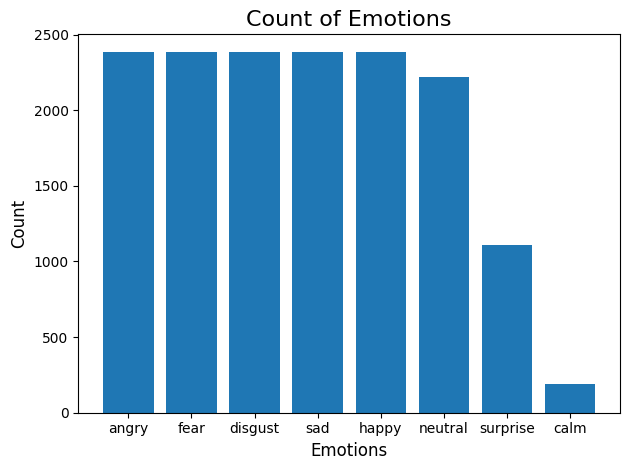

In [289]:
# Count how many of each emotion there are
counts   = data_path['Emotion'].value_counts()
emotions = counts.index.tolist()
values   = counts.values.tolist()

print(values)
plt.figure()
plt.bar(emotions, values)
plt.title('Count of Emotions', fontsize=16)
plt.xlabel('Emotions', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

We can also plot waveplots and spectograms for audio signals

* Waveplots - Waveplots let us know the loudness of the audio at a given time.
* Spectograms - A spectrogram is a visual representation of the spectrum of frequencies of sound or other signals as they vary with time. It’s a representation of frequencies changing with respect to time for given audio/music signals. I generated it with the Short-time Fourier transform.

In [40]:
def create_waveplot(data, sr, emotion):
    plt.figure(figsize=(10, 3))
    plt.title(f'Waveplot for audio with {emotion} emotion', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

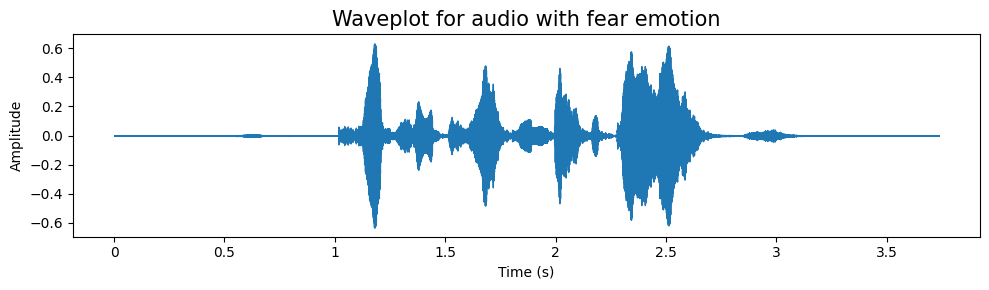

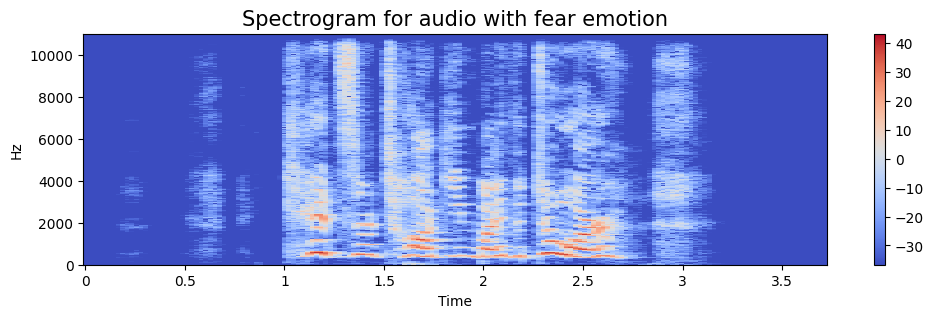

In [283]:
emotion = 'fear'

# grab the 2nd example of that emotion:
paths = data_path['Path'][data_path['Emotion'] == emotion].values
path  = paths[1]  

data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

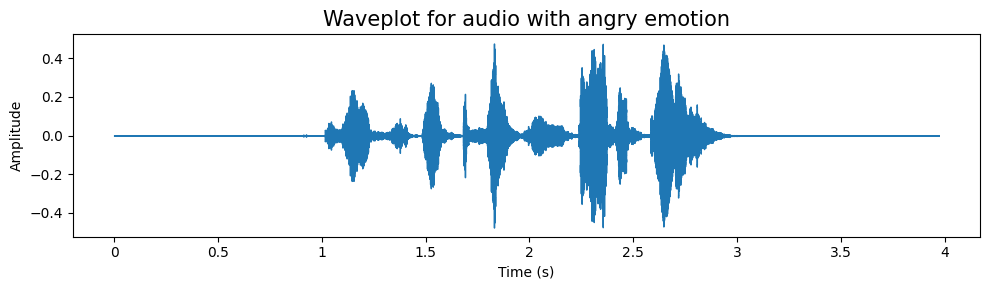

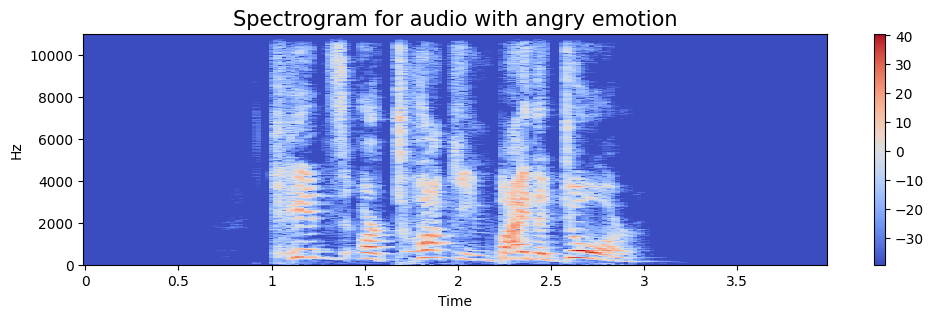

In [284]:
emotion = 'angry'
path = np.array(data_path.Path[data_path.Emotion == emotion])[1]

data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

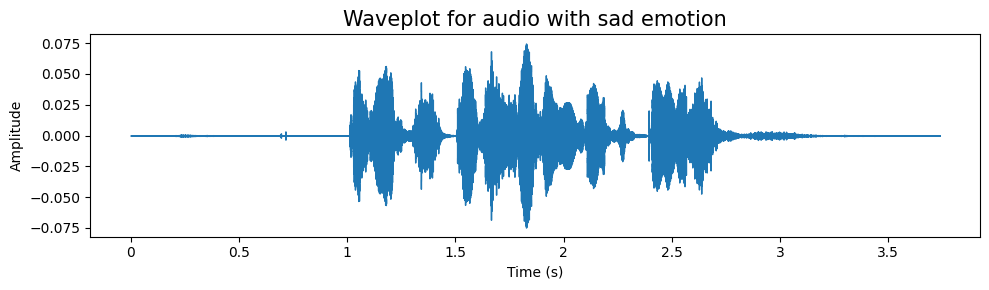

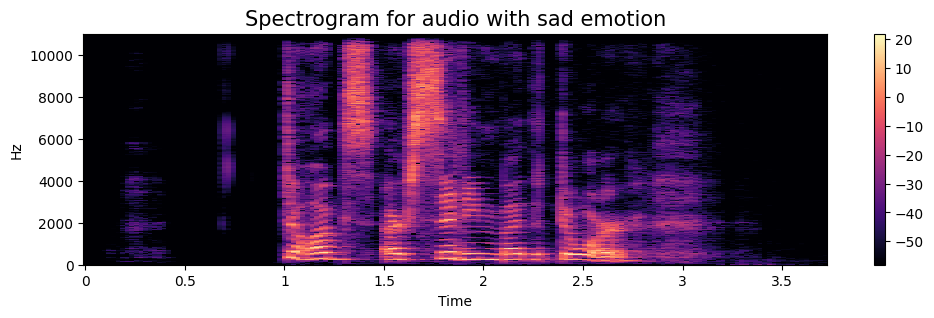

In [285]:
emotion = 'sad'
path = np.array(data_path.Path[data_path.Emotion == emotion])[1]

data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

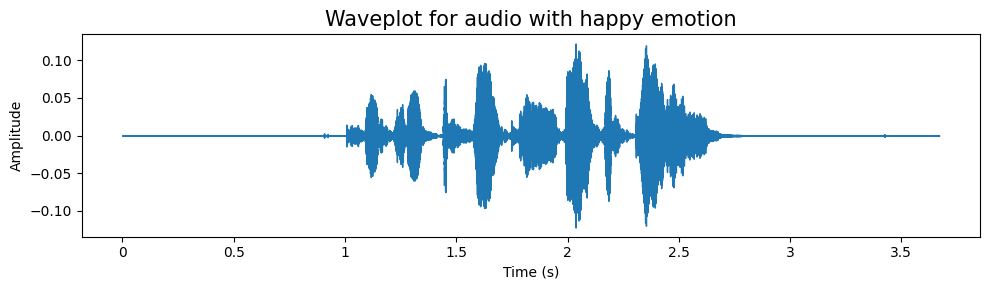

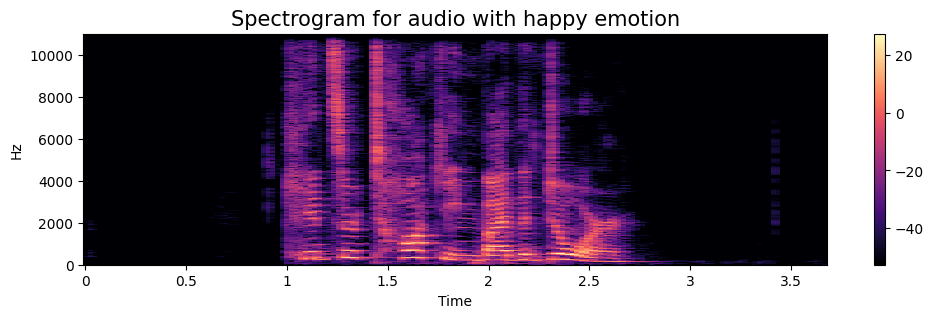

In [44]:
emotion = 'happy'
path = np.array(data_path.Path[data_path.Emotion == emotion])[1]

data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

## Data Augmentation

- Data augmentation is the process by which we create new synthetic data samples by adding small perturbations on our initial training set.
- To generate syntactic data for audio, we can apply noise injection, shifting time, changing pitch and speed.
- The objective is to make our model invariant to those perturbations and enhace its ability to generalize.
- In order to this to work adding the perturbations must conserve the same label as the original training sample.
- In images data augmention can be performed by shifting the image, zooming, rotating ...

In [45]:
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def stretch(data, rate=0.8):
    # Convert to STFT
    stft_data = librosa.stft(data)
    # Apply time stretching
    stft_stretch = librosa.phase_vocoder(stft_data, rate=rate)
    # Convert back to waveform
    return librosa.istft(stft_stretch)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

#### 1. Simple Audio

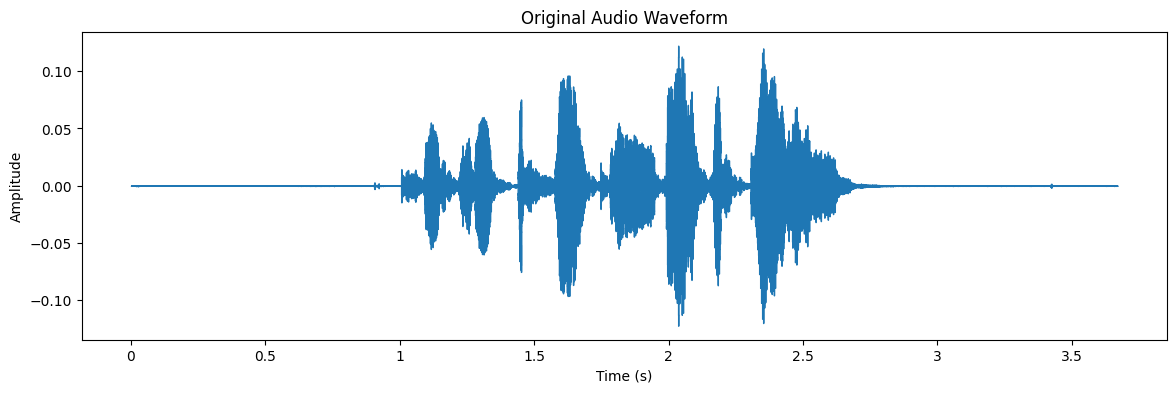

In [46]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=data, sr=sampling_rate)
plt.title("Original Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Audio(path)

#### 2. Noise Injection

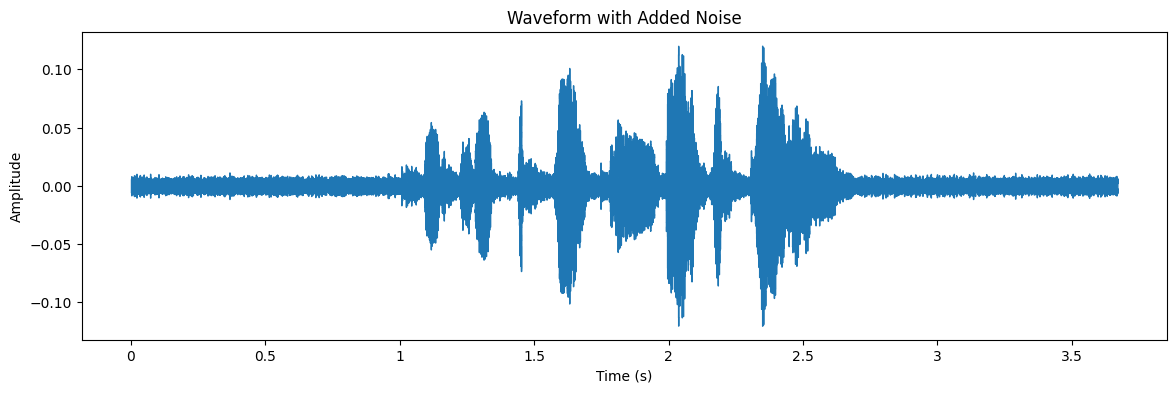

In [47]:
x = noise(data)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sampling_rate)
plt.title("Waveform with Added Noise")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Audio(x, rate=sampling_rate)

We can see noise injection is a very good augmentation technique because of which we can assure our training model is not overfitted

#### 3. Stretching

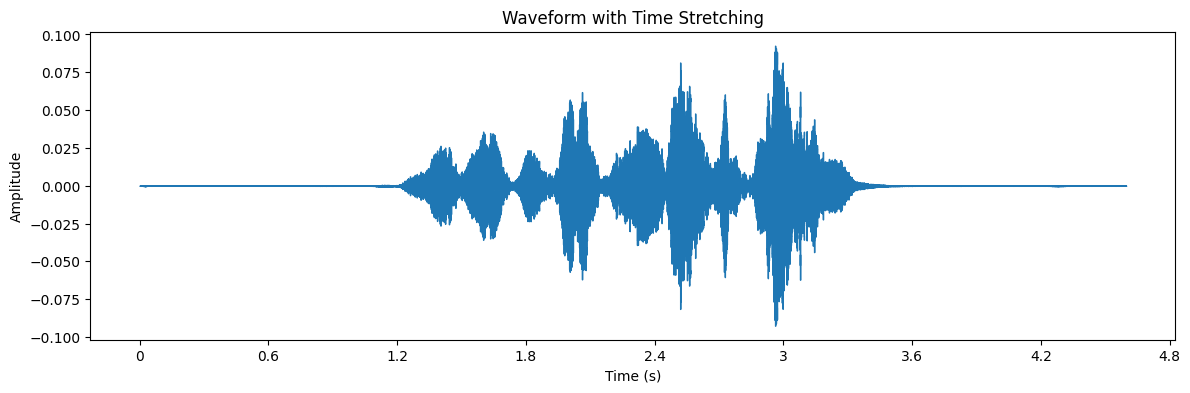

In [48]:
x = stretch(data)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sampling_rate)
plt.title("Waveform with Time Stretching")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Audio(x, rate=sampling_rate)

#### 4. Shifting

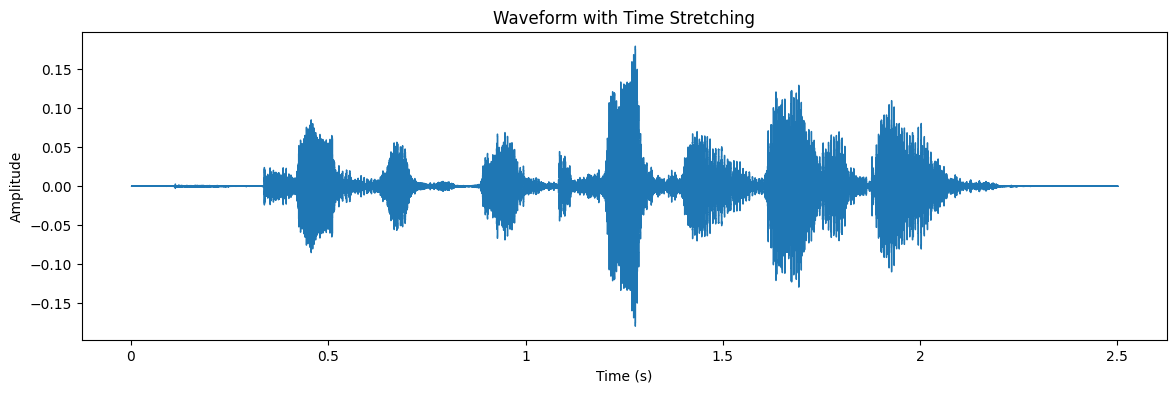

In [156]:
x = shift(data)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sampling_rate)
plt.title("Waveform with Time Stretching")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Audio(x, rate=sampling_rate)

#### 5. Pitch

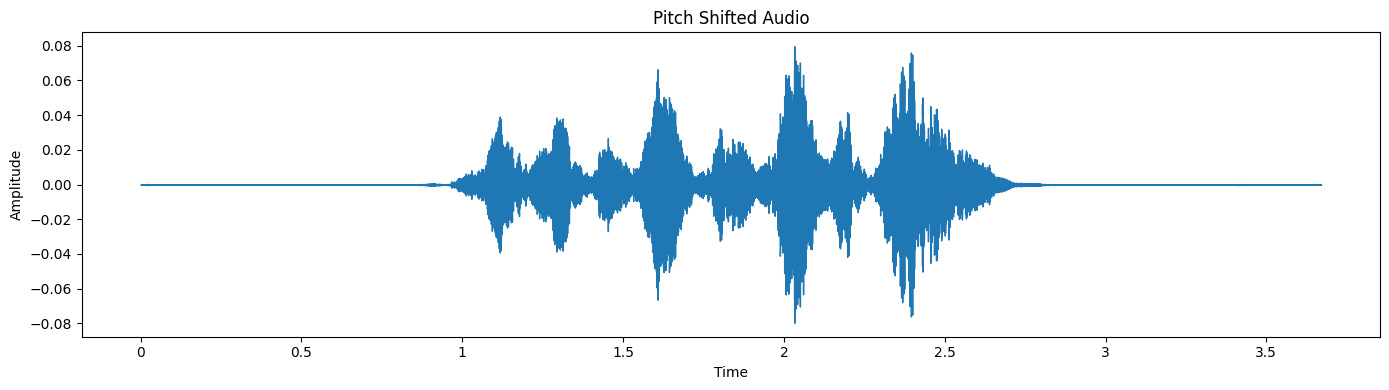

In [50]:
x = pitch(data, sampling_rate)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sampling_rate)
plt.title("Pitch Shifted Audio")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

Audio(x, rate=sampling_rate)

- From the above types of augmentation techniques i am using noise, stretching(ie. changing speed) and some pitching.

## Feature Extraction
- Extraction of features is a very important part in analyzing and finding relations between different things. As we already know that the data provided of audio cannot be understood by the models directly so we need to convert them into an understandable format for which feature extraction is used.


The audio signal is a three-dimensional signal in which three axes represent time, amplitude and frequency.

![image.png](https://miro.medium.com/max/633/1*7sKM9aECRmuoqTadCYVw9A.jpeg)

The audio signals and feature extraction on audio files is based on the blog written by [Askash Mallik](https://medium.com/heuristics/audio-signal-feature-extraction-and-clustering-935319d2225) on feature extraction.

As stated there with the help of the sample rate and the sample data, one can perform several transformations on it to extract valuable features out of it.
1. Zero Crossing Rate : The rate of sign-changes of the signal during the duration of a particular frame.
2. Energy : The sum of squares of the signal values, normalized by the respective frame length.
3. Entropy of Energy : The entropy of sub-frames’ normalized energies. It can be interpreted as a measure of abrupt changes.
4. Spectral Centroid : The center of gravity of the spectrum.
5. Spectral Spread : The second central moment of the spectrum.
6. Spectral Entropy :  Entropy of the normalized spectral energies for a set of sub-frames.
7. Spectral Flux : The squared difference between the normalized magnitudes of the spectra of the two successive frames.
8. Spectral Rolloff : The frequency below which 90% of the magnitude distribution of the spectrum is concentrated.
9.  MFCCs Mel Frequency Cepstral Coefficients form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
10. Chroma Vector : A 12-element representation of the spectral energy where the bins represent the 12 equal-tempered pitch classes of western-type music (semitone spacing).
11. Chroma Deviation : The standard deviation of the 12 chroma coefficients.


I am only extracting 5 features:
- Zero Crossing Rate
- Chroma_stft
- MFCC
- RMS(root mean square) value
- MelSpectogram to train our model.

In [171]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sampling_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sampling_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sampling_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally
    
    return result

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)
    
    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)
    
    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    
    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically
    
    return result

In [52]:
X, Y = [], []
for path, emotion in zip(data_path.Path, data_path.Emotion):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

In [53]:
len(X), len(Y), data_path.Path.shape

(46326, 46326, (15442,))

In [54]:
Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.204540,0.522053,0.470343,0.491423,0.560348,0.548751,0.613287,0.551326,0.534302,0.608861,...,0.006682,0.004037,0.004855,0.004624,0.005723,0.006007,0.006103,0.005150,0.000251,angry
1,0.355279,0.680922,0.680049,0.708421,0.734648,0.730767,0.709192,0.630584,0.638274,0.723447,...,0.011252,0.008563,0.008829,0.009013,0.009747,0.010028,0.010794,0.009865,0.004452,angry
2,0.218414,0.587932,0.490766,0.457135,0.494863,0.554427,0.518937,0.604227,0.513102,0.529382,...,0.002836,0.001973,0.000855,0.000920,0.001194,0.000980,0.001365,0.000594,0.000053,angry
3,0.189815,0.559744,0.520431,0.484952,0.440133,0.394636,0.402852,0.411464,0.440253,0.506417,...,0.002601,0.002952,0.003851,0.003154,0.002964,0.002586,0.002761,0.001653,0.000115,fear
4,0.302508,0.723764,0.725500,0.721197,0.674322,0.651881,0.588228,0.554959,0.578914,0.617897,...,0.002801,0.003125,0.004096,0.003297,0.003144,0.002776,0.002948,0.001833,0.000302,fear


* We have applied data augmentation and extracted the features for each audio files and saved them.

## Data Preparation

- As of now we have extracted the data, now we need to normalize and split our data for training and testing.

In [55]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values

In [ ]:
# As this is a multiclass classification problem onehotencoding our Y.
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [57]:
# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((34744, 162), (34744, 8), (11582, 162), (11582, 8))

In [58]:
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((34744, 162), (34744, 8), (11582, 162), (11582, 8))

In [59]:
# making our data compatible to model.
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((34744, 162, 1), (34744, 8), (11582, 162, 1), (11582, 8))

In [179]:
# Saving the scaler and the encoder
joblib.dump(scaler,  'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

## Modelling

In [60]:
model=Sequential()
model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2))

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=8, activation='softmax'))
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 162, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 81, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 81, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 41, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 41, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 21, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        22,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,288 (2.13 MB)

 Trainable params: 557,288 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=0, patience=2, min_lr=0.0000001)
history=model.fit(x_train, y_train, batch_size=64, epochs=50, validation_data=(x_test, y_test), callbacks=[rlrp])

Epoch 1/50


543/543 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.3157 - loss: 1.7132 - val_accuracy: 0.5277 - val_loss: 1.2242 - learning_rate: 0.0010
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.5119 - loss: 1.2422 - val_accuracy: 0.5643 - val_loss: 1.0798 - learning_rate: 0.0010
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - accuracy: 0.5613 - loss: 1.1188 - val_accuracy: 0.5881 - val_loss: 1.0290 - learning_rate: 0.0010
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.5867 - loss: 1.0533 - val_accuracy: 0.5939 - val_loss: 0.9970 - learning_rate: 0.0010
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.5897 - loss: 1.0259 - val_accuracy: 0.6160 - val_loss: 0.9603 - learning_rate: 0.0010
Epoch 6/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.6045 - loss: 0.9931 - val_accuracy: 0.6177 - val_loss: 0.9497 - learning_rate: 0.0010
Epoch 7/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.6204 - loss: 0.9567

In [62]:
# Save the model
model.save('SER_model.h5')

362/362 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7072 - loss: 0.8520
Accuracy of our model on test data :  70.51458954811096 %


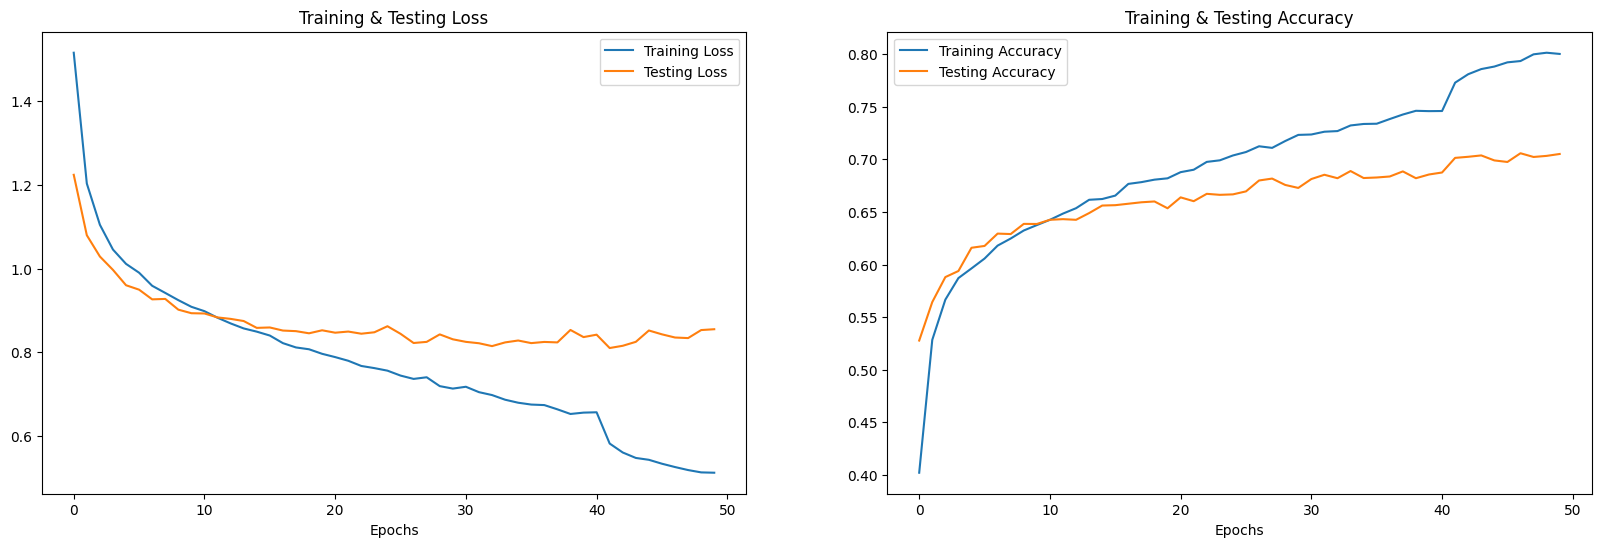

In [64]:
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [65]:
# predicting on test data.
pred_test = model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)

y_test = encoder.inverse_transform(y_test)

362/362 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [66]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test.flatten()

df.head(10)

,Predicted Labels,Actual Labels
0,fear,fear
1,fear,fear
2,angry,angry
3,sad,disgust
4,sad,sad
5,surprise,surprise
6,fear,fear
7,surprise,surprise
8,angry,angry
9,fear,fear


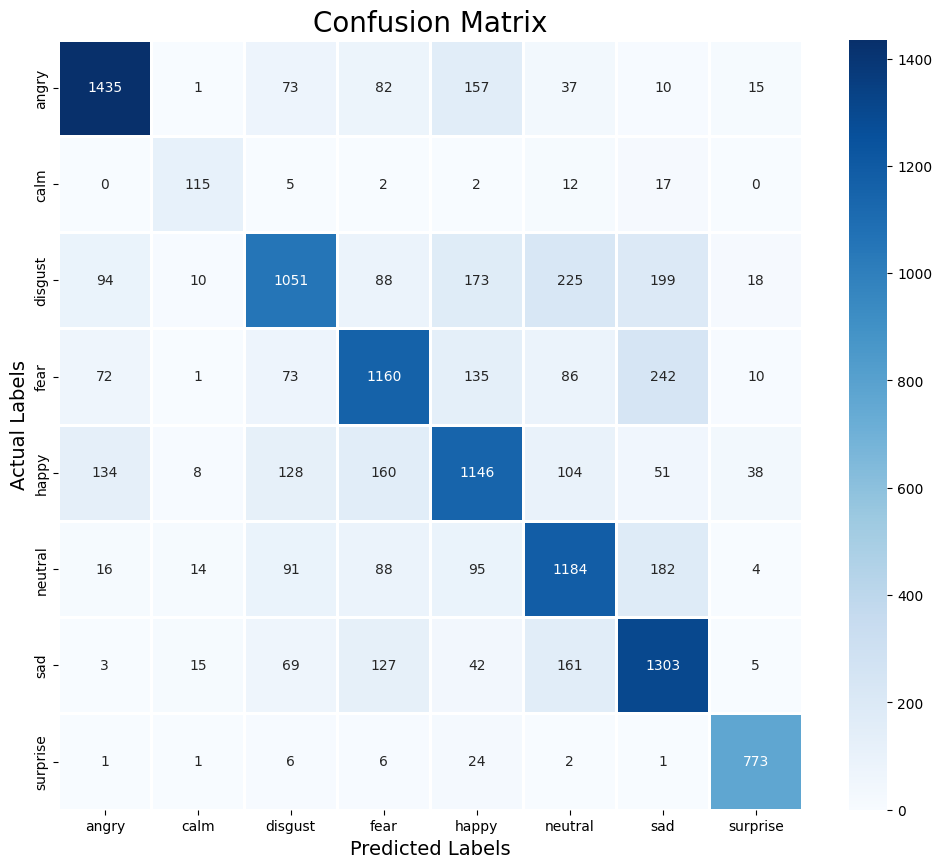

In [67]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.82      0.79      0.81      1810
        calm       0.70      0.75      0.72       153
     disgust       0.70      0.57      0.63      1858
        fear       0.68      0.65      0.66      1779
       happy       0.65      0.65      0.65      1769
     neutral       0.65      0.71      0.68      1674
         sad       0.65      0.76      0.70      1725
    surprise       0.90      0.95      0.92       814

    accuracy                           0.71     11582
   macro avg       0.72      0.73      0.72     11582
weighted avg       0.71      0.71      0.70     11582



- We can see our model is more accurate in predicting surprise, angry emotions and it makes sense also because audio files of these emotions differ to other audio files in a lot of ways like pitch, speed etc..
- We overall achieved 70.51% accuracy on our test data and its decent but we can improve it more by applying more augmentation techniques and using other feature extraction methods or more data.

## Testing  the results

In [192]:
# Load the trained model
model = load_model('SER_model.h5')
scaler  = joblib.load('scaler.pkl')       # StandardScaler()
encoder = joblib.load('encoder.pkl')      # OneHotEncoder()

In [281]:

# Recording configuration
sample_rate = 22050  # Sampling rate (22.05 kHz)
duration = 2.5       # Recording duration in seconds
file_path = "my_audio1.wav"  # Output file name

print("Recording...")
audio = sd.rec(int(sample_rate * duration), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()  # Wait for the recording to finish
print("Recording finished.")

# Save the audio as a WAV file
write(file_path, sample_rate, (audio * 32767).astype('int16'))  # Convert float32 to int16
print(f"File saved as {file_path}")

Recording...
Recording finished.
File saved as my_audio1.wav


In [282]:
# Load and trim the audio
file_path = "my_audio1.wav"
data, sr = librosa.load(file_path, sr=22050, duration=2.5, offset=0.6)

# Extract the feature vector
feats = extract_features(data)           # returns shape (n_feats,)

# Scaling and reshaping to (1, n_feats, 1)
feats_scaled = scaler.transform([feats])  # -> (1, n_feats)
feats_input  = np.expand_dims(feats_scaled, axis=2)  # -> (1, n_feats, 1)

# Prediction
probs    = model.predict(feats_input)     # -> (1, 8)
pred_idx = probs.argmax(axis=1)[0]        # class index

# Retrieve the original label order
class_list = encoder.categories_[0].tolist()  
pred_emotion = class_list[pred_idx]

print(f"Predicted class index: {pred_idx}")
print(f"Predicted emotion: {pred_emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted class index: 2
Predicted emotion: disgust
